# Assignment 1: Environment, Return Engineering, and Portfolio Display

This notebook preserves the completed solution logic and reorganizes it for
exam revision. Each question contains an English problem summary, an
independently runnable solution, Chinese line-level hints, and result guidance.

## Questions

1. Environment inspection
2. Multi-stock cleaning and quarterly returns
3. Mean tests, Sharpe ratios, and wealth growth

## Recommended Answer Structure

1. State the financial or statistical objective.
2. Identify inputs, assumptions, and units.
3. Write the main formula or algorithm before coding.
4. Complete the code in execution order.
5. Report and interpret the result.
6. Add a short validation or reasonableness check.

## Assignment Review Checklist

- Each question can run independently.
- Imports are included in the question's own code cell.
- Random simulations use a fixed seed.
- The final answer includes interpretation, not only printed output.
- Any chart is discussed in the result Markdown.


## Question 1: Environment Inspection

Inspect Python and the core numerical finance packages. Working-directory changes are intentionally excluded as a finance knowledge module.


### Structured Review

- **Purpose:** State what the code calculates and why the quantity matters in finance.
- **Inputs:** Identify the required data, parameter units, and expected data type.
- **Process:** Follow the transformation in execution order rather than reading only the final line.
- **Output:** Connect the printed value to an economic or statistical interpretation.

### Exam Focus

- Identify the lines most likely to be removed in a code-completion question.
- Trace dimensions, indices, and units through each intermediate variable.
- Use a small numerical example to check the direction and scale of the answer.

### Common Mistakes

- Reusing a variable with a different meaning.
- Depending on a previous notebook cell for an import or intermediate object.
- Reporting a number without explaining its financial meaning.


In [1]:
'''
本题检查 Python、NumPy、SciPy 和 numpy_financial 环境。
dir() 可用于探索包中公开的函数名称。
'''
import sys
import numpy as np
import scipy
import numpy_financial as npf

# 过滤下划线开头的内部名称，只保留公开对象
financial_functions = [name for name in dir(npf) if not name.startswith("_")]

print("Python =", sys.version.split()[0])
print("NumPy =", np.__version__)
print("SciPy =", scipy.__version__)
print("numpy-financial functions =", financial_functions)


Python = 3.13.13
NumPy = 2.4.6
SciPy = 1.17.1
numpy-financial functions = ['fv', 'ipmt', 'irr', 'mirr', 'nper', 'npv', 'pmt', 'ppmt', 'pv', 'rate']


**Result interpretation.** The environment exposes functions such as `pv`, `fv`, `npv`, `irr`, and `rate`.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## Question 2: Multi-Stock Cleaning and Quarterly Returns

Create three financially plausible price paths, repair an isolated price gap, and compound daily returns by quarter.


### Structured Review

- **Data source:** Record where the observations come from and whether the example is online, local, or simulated.
- **Cleaning:** Inspect missing values, data types, date order, and duplicated observations before calculating returns.
- **Transformation:** Use adjacent prices for one-period returns and compounding for multi-period returns.
- **Storage:** Choose CSV for portability and pickle only for trusted Python workflows that need preserved data types.

### Formula and Workflow

1. Sort observations by date.
2. Clean the price series without inventing unsupported returns.
3. Calculate simple or log returns.
4. Aggregate with products of growth factors or sums of log returns.
5. Validate one observation manually.

### Exam Focus

- Complete `P_t / P_(t-1) - 1`, `log(P_t/P_(t-1))`, and `prod(1+R)-1`.
- Distinguish price filling from return filling.
- Explain why averaging daily returns is not the exact monthly return.

### Common Mistakes

- Calculating returns on unsorted dates.
- Keeping the first missing return in a statistical test.
- Treating a percentage value as if it were already a decimal.


In [2]:
'''
本题生成三只股票的价格路径，前向填充缺失价格，并计算季度复合收益率。
所有中间数据都在本单元创建，因此可独立运行。
'''
import numpy as np

rng = np.random.default_rng(2026)
tickers = ["AAPL", "MSFT", "GOOGL"]
n_days = 504
daily_log_returns = rng.normal([0.0005, 0.0004, 0.00045], [0.015, 0.013, 0.016], (n_days, 3))
prices = 100 * np.exp(np.cumsum(daily_log_returns, axis=0))
prices[5, 0] = np.nan

# 对每一只股票分别进行前向填充
for column in range(prices.shape[1]):
    for row in range(1, prices.shape[0]):
        if np.isnan(prices[row, column]):
            prices[row, column] = prices[row - 1, column]

# 由相邻价格计算日收益率
returns = prices[1:] / prices[:-1] - 1
quarter_labels = np.repeat(np.arange(1, 9), 63)[: len(returns)]

quarterly = {}
for quarter in np.unique(quarter_labels):
    selected = returns[quarter_labels == quarter]
    # axis=0 表示分别对三只股票的日增长因子连乘
    quarterly[int(quarter)] = np.prod(1 + selected, axis=0) - 1

print("Tickers =", tickers)
for quarter, values in list(quarterly.items())[:4]:
    print("Quarter", quarter, np.round(values, 4))


Tickers = ['AAPL', 'MSFT', 'GOOGL']
Quarter 1 [0.1062 0.0101 0.304 ]
Quarter 2 [0.0589 0.02   0.1111]
Quarter 3 [-0.0455  0.0651  0.15  ]
Quarter 4 [-0.1003  0.1347  0.0505]


**Result interpretation.** The result is a three-element return vector for each quarter, with compounding performed independently by asset.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## Question 3: Mean Tests, Sharpe Ratios, and Growth of One Dollar

Compare two mean returns, calculate annualized Sharpe ratios, and produce the final value of a one-dollar investment.


### Structured Review

- **Return basis:** Use excess return when the model or performance measure requires subtraction of the risk-free rate.
- **Risk denominator:** Match total risk, beta, or downside deviation to the correct measure.
- **Factor exposure:** Interpret each slope as sensitivity to a named systematic factor.
- **Model comparison:** Prefer adjusted R-squared when models contain different numbers of factors.

### Measure Map

| Measure | Numerator | Denominator |
|---|---|---|
| Sharpe | Mean excess return | Total standard deviation |
| Treynor | Mean excess return | Beta |
| Sortino | Mean excess return | Downside deviation |
| Jensen alpha | Realized minus CAPM-predicted return | None |

### Exam Focus

- Identify the correct denominator from the measure name.
- Keep factor returns and asset returns in the same units and frequency.
- State the null hypothesis for an individual t-test and the overall F-test.

### Common Mistakes

- Using total return instead of excess return in a factor regression.
- Comparing raw R-squared across models with different factor counts.
- Minimizing the positive Sharpe ratio instead of minimizing its negative.


In [3]:
'''
本题计算 Welch t 检验、年化 Sharpe Ratio 和累计财富。
年化时日均超额收益与日波动率都基于 252 个交易日。
'''
import numpy as np
from scipy import stats

rng = np.random.default_rng(2027)
returns = rng.normal([0.0006, 0.0005, 0.0007], [0.015, 0.013, 0.016], (503, 3))
tickers = ["AAPL", "MSFT", "GOOGL"]

# Welch 检验不要求两组收益率方差相等
test = stats.ttest_ind(returns[:, 0], returns[:, 1], equal_var=False)

annual_rf = 0.01
daily_rf = (1 + annual_rf) ** (1 / 252) - 1

# Sharpe 年化：日超额收益均值/日标准差 × sqrt(252)
sharpe = (returns.mean(axis=0) - daily_rf) / returns.std(axis=0, ddof=1) * np.sqrt(252)

# cumprod 对增长因子连乘，最后一行是 1 元投资的期末价值
final_wealth = np.cumprod(1 + returns, axis=0)[-1]

print("Mean-test p-value =", round(float(test.pvalue), 6))
print("Sharpe ratios =", dict(zip(tickers, np.round(sharpe, 3))))
print("Final value of $1 =", dict(zip(tickers, np.round(final_wealth, 3))))


Mean-test p-value = 0.271732
Sharpe ratios = {'AAPL': np.float64(-0.156), 'MSFT': np.float64(1.018), 'GOOGL': np.float64(1.019)}
Final value of $1 = {'AAPL': np.float64(0.887), 'MSFT': np.float64(1.501), 'GOOGL': np.float64(1.614)}


**Result interpretation.** The p-value addresses statistical mean differences; Sharpe and terminal wealth address risk-adjusted and cumulative performance.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

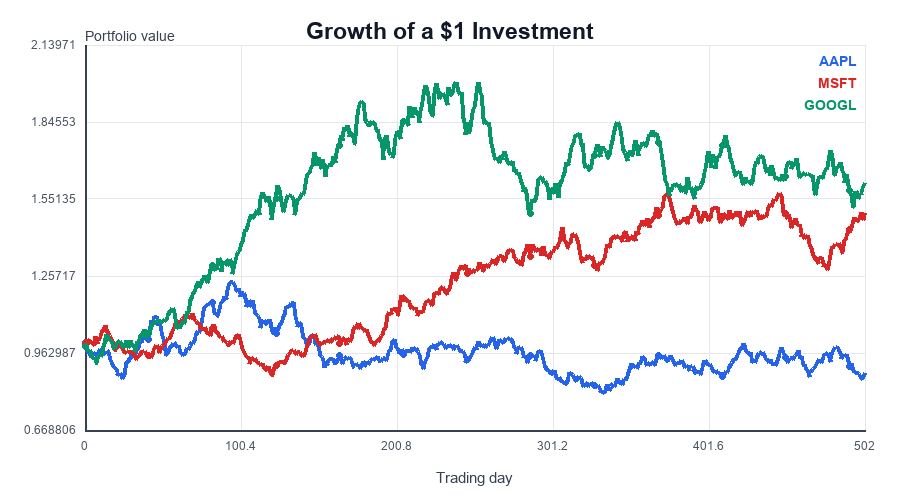
